## SUSAN Corner Detection + Convex Hull Thresholding

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("✓ All libraries imported successfully!")
print("Note: Only numpy, matplotlib, and PIL used - no CV libraries!")

✓ All libraries imported successfully!
Note: Only numpy, matplotlib, and PIL used - no CV libraries!


### Helper Functions to Avoid Using the pre defined functions

In [141]:
def manual_append(mask_list, element):
    """
    Manually append element to list without using .append()
    
    Parameters:
    -----------
    mask_list : list
        Original list
    element : any
        Element to append
        
    Returns:
    --------
    new_list : list
        New list with element appended
    """
    new_list = [0] * (len(mask_list) + 1)
    for i in range(len(mask_list)):
        new_list[i] = mask_list[i]
    new_list[len(mask_list)] = element
    return new_list

In [142]:
def manual_min(arr):
    """
    Find minimum value in array without using predefined min()
    
    Parameters:
    -----------
    arr : numpy array
        Input array
        
    Returns:
    --------
    min_val : float
        Minimum value in array
    """
    flat_arr = arr.flatten()
    min_val = flat_arr[0]
    for i in range(1, len(flat_arr)):
        if flat_arr[i] < min_val:
            min_val = flat_arr[i]
    return min_val

In [143]:
def manual_max(arr):
    """
    Find maximum value in array without using predefined max()
    
    Parameters:
    -----------
    arr : numpy array
        Input array
        
    Returns:
    --------
    max_val : float
        Maximum value in array
    """
    flat_arr = arr.flatten()
    max_val = flat_arr[0]
    for i in range(1, len(flat_arr)):
        if flat_arr[i] > max_val:
            max_val = flat_arr[i]
    return max_val

In [144]:
def manual_argmax (array):
    """
    Custom implementation of argmax - finds index of maximum value in array
    
    Parameters:
    -----------
    array : numpy array or list
        Input array to find maximum index
    
    Returns:
    --------
    max_idx : int
        Index of the maximum value in the array
    """
    max_val = array[0]
    max_idx = 0
    
    for i in range(1, len(array)):
        if array[i] > max_val:
            max_val = array[i]
            max_idx = i
    
    return max_idx

### 1. SUSAN Implementation

In [145]:
def circular_mask(radius):
    """
    Create circular mask - get pixels positions inside the mask
    
    Parameters:
    -----------
    radius : int
        Radius of circular mask
        
    Returns:
    --------
    mask : list of tuples
        List of (x, y) coordinate offsets from center
    """
    mask = []
    # up and down
    for a in range(-radius, radius + 1):
        # right and left
        for b in range(-radius, radius + 1): 
                mask = manual_append(mask, (b, a))
    return mask

In [146]:
def susan_histogram(scores, bins=256):
    """
    Create histogram from SUSAN scores without using np.histogram
    
    Parameters:
    -----------
    scores : 2D numpy array
        SUSAN scores for each pixel (should be interior region only)
    bins : int, optional
        Number of bins for histogram (default: 256)
        
    Returns:
    --------
    hist : 1D numpy array
        Histogram of SUSAN scores
    bin_edges : 1D numpy array
        Bin edges for the histogram
    """
    minv = manual_min(scores)
    maxv = manual_max(scores)
    
    hist = np.zeros(bins, dtype=np.int32)
    bin_width = (maxv - minv) / bins
    flat_scores = scores.flatten()
    
    # manual histogram calculation
    for value in flat_scores:
        
        if bin_width > 0:
            bin_idx = int((value - minv) / bin_width)
            
            if bin_idx >= bins:
                bin_idx = bins - 1
                
        else:
            bin_idx = 0
    
        hist[bin_idx] += 1
    
    bin_edges = np.zeros(bins + 1, dtype=np.float32)
    for i in range(bins + 1):
        bin_edges[i] = minv + i * bin_width
    
    return hist, bin_edges

In [147]:
def susan(image, t, radius=3):
    """
    SUSAN Corner Detection Algorithm
    
    Calculates USAN (Univalue Segment Assimilating Nucleus) size for each pixel
    using the comparison function: c(m) = e^(-((I(m)-I(m₀))/t)^6)
    
    Parameters:
    -----------
    image : 2D numpy array
        Input grayscale image
    t : float
        Brightness difference threshold (tunable parameter)
    radius : int, optional
        Radius of circular mask (default: 3)
        
    Returns:
    --------
    scores : 2D numpy array
        USAN size for each pixel (corner response)
    """
    h, w = image.shape
    
    img = image.astype(np.float32)
    
    mask = circular_mask(radius)
    
    scores = np.zeros((h, w), dtype=np.float32)
    max_score = len(mask)  # Maximum possible USAN (number of pixels in mask)
    
    for y in range(radius, h - radius):
        for x in range(radius, w - radius):
           # nucleus
            center_intensity = img[y, x]
            
            usan_size = 0.0
            
            for b, a in mask:

                ny = y + a
                nx = x + b
                
                neighbor_intensity = img[ny, nx]
                
                intensity_diff = neighbor_intensity - center_intensity
                
                c_m = np.exp(-((intensity_diff / t) ** 6))
                
                usan_size += c_m
            
            # Invert: small USAN (corners) -> high score (bright)
            scores[y, x] = max_score - usan_size
    
    return scores

### 2. Convex Hull Implementation + Two Pass Threshold Implementation

#### 2.a Convex Hull Implementation

In [148]:
def CalculateHullPoints(histogram):
    """
    Calculate convex hull points
    
    Algorithm :
    1. For color intensity i, find intensity j that gives maximum slope
    2. After getting maximum slope at j, let i = j
    3. Repeat until i = 254, making j start from 255
    
    Parameters:
    -----------
    histogram : 1D numpy array
        Histogram of image intensities
        
    Returns:
    --------
    hull_points : list of tuples
        List of (start, end) tuples representing convex hull segments
    """
    n = len(histogram)
    hull_points = []
    
    i = 0
    
    while i < n - 1:
        max_slope = -np.inf
        best_j = i + 1

        for j in range(i + 1, n):  # here i is fixed and j varies from i+1 to 255
            slope = (histogram[j] - histogram[i]) / (j - i)
            
            if slope > max_slope:
                max_slope = slope
                best_j = j
        
        hull_points.append((i, best_j))
        
        i = best_j 
        
        if i >= n - 1:
            break
    
    return hull_points

In [149]:
def GetHullValues(hull_points, histogram):
    """
    Calculate hull values using straight line equation: y = mx + c
    
    Parameters:
    -----------
    hull_points : list of tuples
        List of (start, end) tuples from convex hull
    histogram : 1D numpy array
        Original histogram
    
    Returns:
    --------
    hull_values : 1D numpy array
        Hull values for each intensity calculated using line equation
    """
    n = len(histogram)
    hull_values = np.zeros(n, dtype=np.float32)
    
    for start, end in hull_points:
        if start == end:
            hull_values[start] = histogram[start]
            continue
        
        h_i = histogram[start]  
        h_j = histogram[end]    
        
        m = (h_j - h_i) / (end - start)
        
        c = h_i - m * start
        
        for x in range(start, end + 1):
            hull_values[x] = m * x + c
    
    return hull_values

In [150]:
def GetThreshold(histogram, hull_values):
    """
    Find threshold with maximum difference between hull and histogram
    
    Formula: Thr = Max_{i=0}^{255}(Hull(i) - Hist(i))
    
    Parameters:
    -----------
    histogram : 1D numpy array
        Original histogram
    hull_values : 1D numpy array
        Convex hull values
    
    Returns:
    --------
    threshold : int
        Optimal threshold value (intensity with maximum difference)
    """
    differences = hull_values - histogram
    
    threshold = manual_argmax(differences)
    
    return int(threshold)

In [151]:
def ApplyThresh(histogram, threshold):
    """
    Split histogram at threshold
    
    Parameters:
    -----------
    histogram : 1D numpy array
        Input histogram
    threshold : int
        Threshold value to split at
    
    Returns:
    --------
    below_thresh : 1D numpy array
        Histogram values below threshold
    above_thresh : 1D numpy array
        Histogram values above threshold
    """
    n = len(histogram)
    
    below_thresh = np.zeros(n, dtype=histogram.dtype)
    above_thresh = np.zeros(n, dtype=histogram.dtype)
    
    for i in range(n):
        if i <= threshold:
            below_thresh[i] = histogram[i]
        else:
            above_thresh[i] = histogram[i]
    
    return below_thresh, above_thresh

#### 2.b Two Pass Threshold Implementation

In [152]:
def two_pass_convex_hull_threshold(histogram):
    """
    Apply convex hull thresholding twice to get two thresholds
    
    Parameters:
    -----------
    histogram : 1D numpy array
        Input histogram
    
    Returns:
    --------
    threshold1 : int
        First threshold (separates corners from edges)
    threshold2 : int
        Second threshold (separates edges from homogeneous regions)
    """    
    # on the full histogram
    hull_points_1 = CalculateHullPoints(histogram)
    hull_values_1 = GetHullValues(hull_points_1, histogram)
    threshold1 = GetThreshold(histogram, hull_values_1)
    
    print(f"Threshold 1 (corners/edges): {threshold1}")
    
    below_t1, above_t1 = ApplyThresh(histogram, threshold1)
        
    # on the above threshold1 part of histogram
    hull_points_2 = CalculateHullPoints(above_t1)
    hull_values_2 = GetHullValues(hull_points_2, above_t1)
    threshold2 = GetThreshold(above_t1, hull_values_2)
    
    print(f"Threshold 2 (edges/homogeneous): {threshold2}")
    
    if threshold2 <= threshold1:
        threshold2 = threshold1 + max(1, (255 - threshold1) // 3)
        print(f"Adjusted Threshold 2 to: {threshold2}")
    
    return threshold1, threshold2

### 3. Draw Image


In [153]:
def DrawImages(threshold1, threshold2, susan_image):
    """
    Split image into three regions based on thresholds
    
    Input:
    - threshold1: lower threshold
    - threshold2: upper threshold  
    - susan_image: SUSAN response image
    
    Output:
    - lower_region: corners (≤ threshold1)
    - mid_region: edges (threshold1 < x ≤ threshold2)
    - higher_region: homogeneous (> threshold2)
    """
    lower_region = np.zeros_like(susan_image)
    mid_region = np.zeros_like(susan_image)
    higher_region = np.zeros_like(susan_image)


    for i in range(susan_image.shape[0]):
        for j in range(susan_image.shape[1]):
            pixel_value = susan_image[i, j]
            
            if pixel_value <= threshold1:
                lower_region[i, j] = pixel_value
            elif threshold1 < pixel_value <= threshold2:
                mid_region[i, j] = pixel_value
            else:
                higher_region[i, j] = pixel_value
    
    return lower_region, mid_region, higher_region

#### For Visualization 

In [154]:
def plot_comprehensive_results(original, susan_response, histogram, 
                               t1, t2, corners, edges, homogeneous, t_parameter):
    """Create comprehensive visualization"""
    
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f't={t_parameter}: SUSAN Corner Detection Results', fontsize=16, fontweight='bold')
    
    # Row 1: Original, SUSAN, Histogram
    plt.subplot(3, 4, 1)
    plt.imshow(original, cmap='gray')
    plt.title('1. Original Image', fontsize=14, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(3, 4, 2)
    plt.imshow(susan_response, cmap='gray')
    plt.title('2. SUSAN Response', fontsize=14, fontweight='bold')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    
    plt.subplot(3, 4, 3)
    x = np.arange(len(histogram))
    plt.plot(x, histogram, 'b-', linewidth=2)
    plt.axvline(t1, color='r', linestyle='--', linewidth=2, label=f'T1={t1}')
    plt.axvline(t2, color='g', linestyle='--', linewidth=2, label=f'T2={t2}')
    plt.title('3. Histogram + Thresholds', fontsize=14, fontweight='bold')
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 4, 4)
    plt.plot(x, np.log1p(histogram), 'b-', linewidth=2)
    plt.axvline(t1, color='r', linestyle='--', linewidth=2)
    plt.axvline(t2, color='g', linestyle='--', linewidth=2)
    plt.title('4. Histogram (Log)', fontsize=14, fontweight='bold')
    plt.xlabel('Intensity')
    plt.ylabel('Log(Frequency)')
    plt.grid(True, alpha=0.3)
    
    # Row 2: Three regions (intensity)
    plt.subplot(3, 4, 5)
    plt.imshow(corners, cmap='gray')
    plt.title(f'5. CORNERS\n(≤ {t1})', fontsize=14, fontweight='bold')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    
    plt.subplot(3, 4, 6)
    plt.imshow(edges, cmap='gray')
    plt.title(f'6. EDGES\n({t1} < x ≤ {t2})', fontsize=14, fontweight='bold')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    
    plt.subplot(3, 4, 7)
    plt.imshow(homogeneous, cmap='gray')
    plt.title(f'7. HOMOGENEOUS\n(> {t2})', fontsize=14, fontweight='bold')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    
    # Row 3: Binary versions
    # plt.subplot(3, 4, 9)
    # binary_corners = (corners > 0).astype(np.uint8) * 255
    # plt.imshow(binary_corners, cmap='gray')
    # plt.title('8. Corners (Binary)', fontsize=14, fontweight='bold')
    # plt.axis('off')
    
    # plt.subplot(3, 4, 10)
    # binary_edges = (edges > 0).astype(np.uint8) * 255
    # plt.imshow(binary_edges, cmap='gray')
    # plt.title('9. Edges (Binary)', fontsize=14, fontweight='bold')
    # plt.axis('off')
    
    # plt.subplot(3, 4, 11)
    # binary_homog = (homogeneous > 0).astype(np.uint8) * 255
    # plt.imshow(binary_homog, cmap='gray')
    # plt.title('10. Homogeneous (Binary)', fontsize=14, fontweight='bold')
    # plt.axis('off')
    
    # # Combined RGB view
    # plt.subplot(3, 4, 9)
    # combined = np.zeros((*susan_response.shape, 3), dtype=np.uint8)
    # combined[:, :, 0] = (corners > 0).astype(np.uint8) * 255      # Red
    # combined[:, :, 1] = (edges > 0).astype(np.uint8) * 255        # Green
    # combined[:, :, 2] = (homogeneous > 0).astype(np.uint8) * 255  # Blue
    # plt.imshow(combined)
    # plt.title('11. Combined\n(R=Corners, G=Edges, B=Homog)', 
    #           fontsize=14, fontweight='bold')
    # plt.axis('off')
    
    plt.tight_layout()
    return fig

#### The Complete pipeline

In [155]:
def run_complete_pipeline(image_path, t_parameter=27, radius=3):
    """
    Complete execution pipeline for the assignment
    """    
    print(f"\n📁 Loading image: {image_path}")
    image = Image.open(image_path)
    image_array = np.array(image)
    
    # Convert to grayscale if RGB
    if len(image_array.shape) == 3:
        gray_image = np.mean(image_array, axis=2).astype(np.uint8)
    else:
        gray_image = image_array.astype(np.uint8)
    print(f"✓ Image loaded: {gray_image.shape}")
    
    # Step 1: Run SUSAN to get scores
    susan_response = susan(gray_image, t=t_parameter, radius=radius)
    print("✓ SUSAN response computed.")
    print(f"  SUSAN score range: [{manual_min(susan_response):.2f}, {manual_max(susan_response):.2f}]")
    
    # Extract only the interior (processed) region for histogram
    h, w = susan_response.shape
    interior_scores = susan_response[radius:h-radius, radius:w-radius]
    print(f"  Interior region size: {interior_scores.shape}")
    print(f"  Interior score range: [{manual_min(interior_scores):.2f}, {manual_max(interior_scores):.2f}]")
    
    # Step 2: Create histogram from INTERIOR SUSAN scores only
    histogram, bin_edges = susan_histogram(interior_scores, bins=256)
    print("✓ Histogram created from interior SUSAN scores.")
    
    # Step 3: Apply convex hull thresholding (returns bin indices)
    threshold1_idx, threshold2_idx = two_pass_convex_hull_threshold(histogram)
    print("✓ Convex hull thresholds determined (histogram bin indices).")
    
    # Step 4: Map bin indices to actual SUSAN score values
    threshold1 = bin_edges[threshold1_idx]
    threshold2 = bin_edges[threshold2_idx]
    print(f"  Mapped to SUSAN scores: T1={threshold1:.2f}, T2={threshold2:.2f}")
      
    # Step 5: Segment regions using actual SUSAN score thresholds
    # Apply to FULL image (including borders)
    corners, edges, homogeneous = DrawImages(
        threshold1, threshold2, susan_response
    )
    print("✓ Regions segmented based on thresholds.")
    
    # Statistics
    total_pixels = gray_image.shape[0] * gray_image.shape[1]
    corners_count = np.sum(corners > 0)
    edges_count = np.sum(edges > 0)
    homog_count = np.sum(homogeneous > 0)
    
    print(f"\n📊 Region Statistics:")
    print(f"  Corners:      {corners_count:8d} pixels ({corners_count/total_pixels*100:6.2f}%)")
    print(f"  Edges:        {edges_count:8d} pixels ({edges_count/total_pixels*100:6.2f}%)")
    print(f"  Homogeneous:  {homog_count:8d} pixels ({homog_count/total_pixels*100:6.2f}%)")
    print(f"  Total:        {total_pixels:8d} pixels")
    
    # Visualization
    fig = plot_comprehensive_results(
        gray_image, susan_response, histogram,
        threshold1_idx, threshold2_idx,  # Use indices for histogram visualization
        corners, edges, homogeneous , t_parameter
    )
    
    print("\n✅ Processing complete!")
    print("="*80)
    
    return {
        'susan_response': susan_response,
        'histogram': histogram,
        'threshold1': threshold1,
        'threshold2': threshold2,
        'threshold1_idx': threshold1_idx,
        'threshold2_idx': threshold2_idx,
        'corners': corners,
        'edges': edges,
        'homogeneous': homogeneous,
        'figure': fig
    }


Testing with t=35...

📁 Loading image: test2.png
✓ Image loaded: (329, 495)
✓ SUSAN response computed.
  SUSAN score range: [0.00, 48.00]
  Interior region size: (323, 489)
  Interior score range: [0.00, 48.00]
✓ Histogram created from interior SUSAN scores.
Threshold 1 (corners/edges): 3
Threshold 2 (edges/homogeneous): 3
Adjusted Threshold 2 to: 87
✓ Convex hull thresholds determined (histogram bin indices).
  Mapped to SUSAN scores: T1=0.56, T2=16.31
✓ Regions segmented based on thresholds.

📊 Region Statistics:
  Corners:         51607 pixels ( 31.69%)
  Edges:           58034 pixels ( 35.64%)
  Homogeneous:     28478 pixels ( 17.49%)
  Total:          162855 pixels

✅ Processing complete!


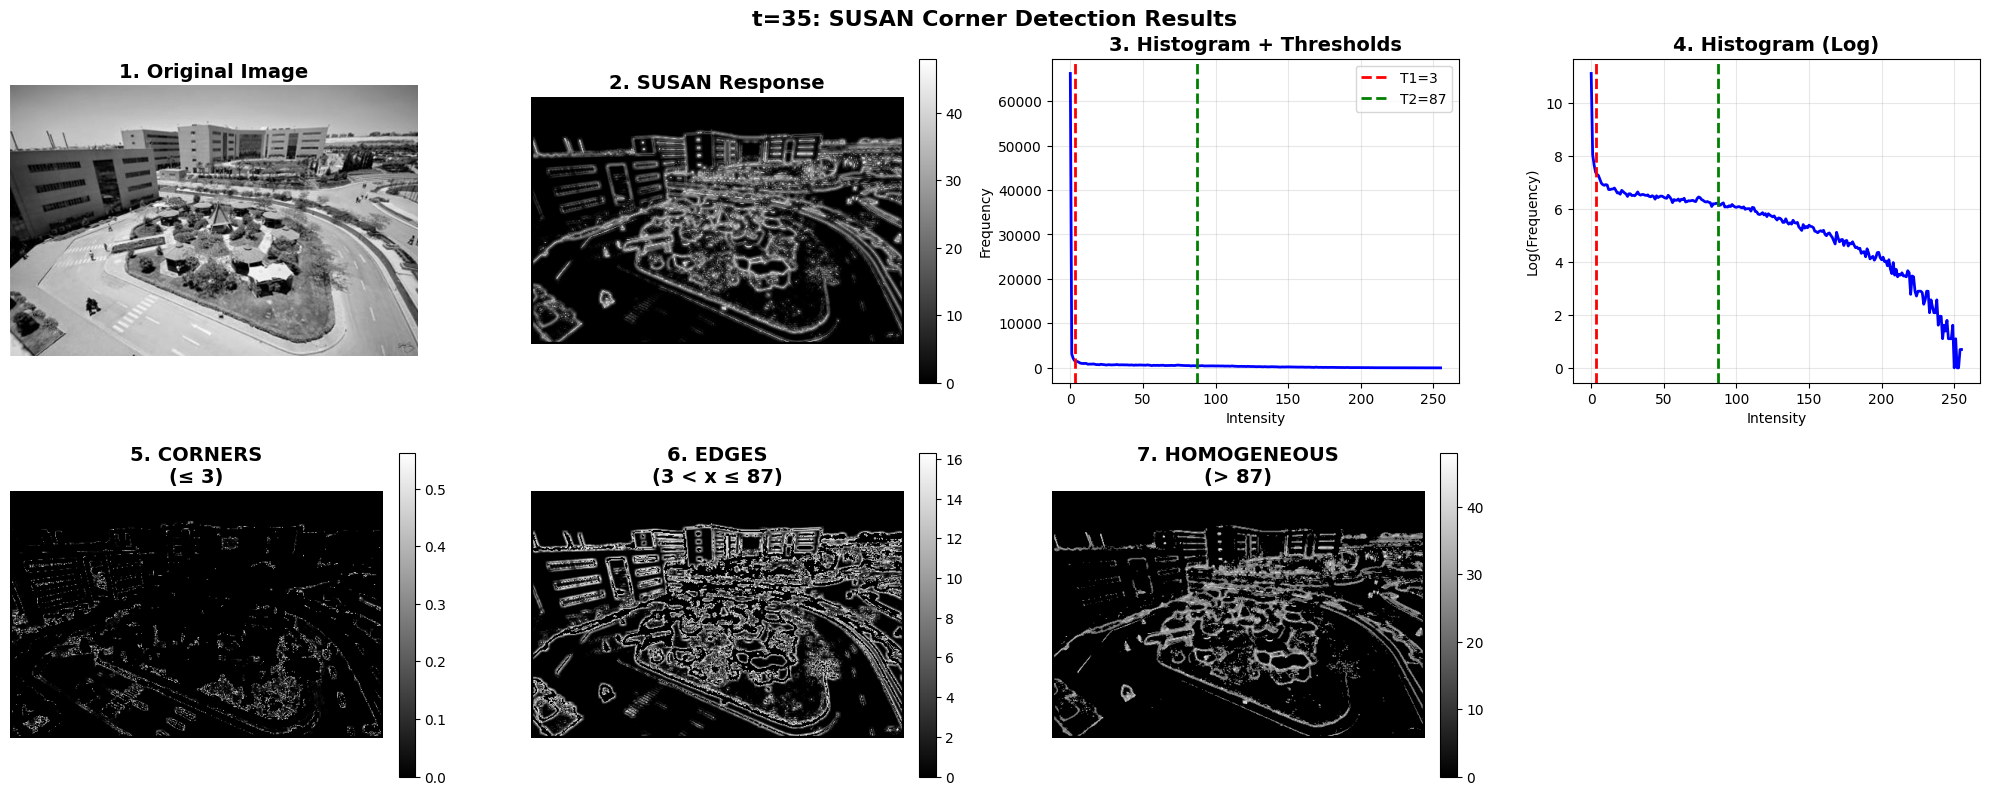

In [156]:
   
image_path = 'test2.png'
# results = run_complete_pipeline(image_path, t_parameter=27, radius=3)
# plt.show()

t_values = [35]

for idx, t in enumerate(t_values):
    print(f"\nTesting with t={t}...")
    result = run_complete_pipeline(image_path, t_parameter=t, radius=3)
